## Settings and imports

In [1]:
import numpy as np
import pandas as pd
import os
import torch
import matplotlib.pyplot as plt
import string
from torch import nn
from torch.utils.data import Dataset, DataLoader
import sklearn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import normalize

In [2]:
object_name = 'Documents_XVIII_century' # Books / Documents_XVIII_century

In [3]:
if object_name == 'Books':
    real_or_simulated = 'real' #simulated / real / all
    #comment: in case of classification problem, we skip augmentation, read below why

keep_sample_together = False #Should all 15 slices from the same sample go together to the same set (train/test)?
if keep_sample_together:
    sample_together = 'sample_together'
else:
    sample_together = 'sample_split'
    
preprocessing_method = 'logarithm' # none / normalization / logarithm

columns_to_keep_inks = {
                        'Books': [
                                                 'Al_inks',
                                                 'S_inks',
                                                 'Cr_inks',
                                                 'Mn_inks',
                                                 'Co_inks',
                                                 'Cu_inks',
                                                 'Zn_inks',
                                                 'Pb_inks'],
    
                        'Documents_XVIII_century' : [
                                                 'Al_inks',
                                                 'S_inks',
                                                 'Cr_inks',
                                                 'Mn_inks',
                                                 'Co_inks',
                                                 'Cu_inks',
                                                 'Zn_inks',
                                                 'Pb_inks'
                                                            ],
    
                        'Konstytucja' : [
                                                 'Al',
                                                 'S',
                                                 'Cr',
                                                 'Mn',
                                                 'Co',
                                                 'Cu',
                                                 'Zn',
                                                 'Pb'
                                                            ]
    
                        }

columns_to_keep_inds = { 
                        'Books' : [
                            
                                                 'Al_inds',
                                                 'S_inds',
                                                 'Cr_inds',
                                                 'Mn_inds',
                                                 'Co_inds',
                                                 'Cu_inds',
                                                 'Zn_inds',
                                                 'Pb_inds'],
    
                        'Documents_XVIII_century' : [
                                                 'Al_inds',
                                                 'S_inds',
                                                 'Cr_inds',
                                                 'Mn_inds',
                                                 'Co_inds',
                                                 'Cu_inds',
                                                 'Zn_inds',
                                                 'Pb_inds'
                                                        ],
                        'Konstytucja' : []
    
                        }

In [4]:
data_path = {'Books' : '../data/DANE.xlsx',
             'Documents_XVIII_century' : '../data/Lipiec_2024.xlsx',
             'Konstytucja' : '../data/Lipiec_2024.xlsx'}

results_path = {'Books' : '../results/Books/',
                'Documents_XVIII_century' : '../results/Documents_XVIII_century/',
                'Konstytucja' : '../results/Konstytucja/'}

figures_path = {'Books' : '../results/visualisations/Books/',
                'Documents_XVIII_century' : '../results/visualisations/Documents_XVIII_century/',
                'Konstytucja': '../results/visualisations/Konstytucja/'}

## Loading the data

In [5]:
df = pd.ExcelFile(data_path[object_name])

if object_name == 'Books':
    if real_or_simulated == 'simulated':
        inks_df = df.parse('a.', header=0, index_col=0, usecols=list)[:1425] #inKs
        inds_df = df.parse('i.', header=0, index_col=0, usecols=list)[:1425]  #inDs
    elif real_or_simulated == 'real':
        inks_df = df.parse('a.', header=0, index_col=0, usecols=list)[1425:] #inKs
        inds_df = df.parse('i.', header=0, index_col=0, usecols=list)[1425:]  #inDs
    elif real_or_simulated == 'all':
        inks_df = df.parse('a.', header=0, index_col=0, usecols=list) #inKs
        inds_df = df.parse('i.', header=0, index_col=0, usecols=list) #inDs

elif object_name == 'Documents_XVIII_century':
    inks_df = df.parse('Arkusz1', header=0, usecols=range(2,29), skiprows=range(3931, 4742))
    inds_df = df.parse('Arkusz1', header=0, usecols=range(32,59), skiprows=range(3931, 4742))
    inds_df.columns = inks_df.columns

## Preprocessing

### Joining corresponding samples from inds and inks into one table

In [6]:
inks_df = inks_df.reset_index(drop=False)
inds_df = inds_df.reset_index(drop=False)
inDKs_df = inds_df.join(inks_df, how='inner', rsuffix='_inks', lsuffix='_inds')

### Keeping track of the records from the same sample

In [7]:
inDKs_df['Sample_id'] = np.repeat(range(int(inDKs_df.shape[0]/15)), 15, axis=0)

### Removing some data

1. Let's keep only columns that we need.

To reduce the set of used elements run cell below. Then, instead of predicting 29 numbers, we will predict only 8. We will also use only 8 numbers as input.

In [8]:
inDKs_df = inDKs_df[columns_to_keep_inks[object_name] + columns_to_keep_inds[object_name] + ['Sample_id']]

2. Let's remove rows with missing values.

In [9]:
(inds_df.shape[0] - inds_df.dropna().shape[0])/inds_df.shape[0]

0.007888040712468193

In [10]:
inds_df.dropna(inplace=True)

### Data augmentation

In case of classification task we skip augmentation, because it's not clear how to perform it and what class to use as label.

### Removing inks values, keeping only inds and classes

In [11]:
inDKs_df = inDKs_df[[col for col in inDKs_df.columns if not col.endswith('_inks')]]

############################

## Creating labels

In [12]:
X = inDKs_df[[col for col in inDKs_df.columns if not col == 'Sample_id']]
X.reset_index(drop=True, inplace=True)
y = pd.get_dummies(inDKs_df['Sample_id'])
y.reset_index(drop=True, inplace=True)
inDKs_df = pd.concat([X,y], axis=1)

In [13]:
inDKs_df.columns = [str(col) for col in inDKs_df.columns]

## Train test split, dataloaders

In [14]:
if keep_sample_together:
    
    indices = list(inDKs_df['Sample_id'].unique())
    
    ind_train, ind_test = train_test_split(indices, test_size=0.2, random_state=1)
    ind_train, ind_val = train_test_split(ind_train, test_size=0.25, random_state=1)
    
    X_y_train = inDKs_df[inDKs_df['Sample_id'].apply(lambda x: x in ind_train)]
    X_y_val = inDKs_df[inDKs_df['Sample_id'].apply(lambda x: x in ind_val)]
    X_y_test = inDKs_df[inDKs_df['Sample_id'].apply(lambda x: x in ind_test)]
    
    X_y_train.reset_index(drop=True, inplace=True)
    X_y_val.reset_index(drop=True, inplace=True)
    X_y_test.reset_index(drop=True, inplace=True)

else:
    indices = list(range(int(inDKs_df.shape[0])))
    ind_train_all, ind_test_all = train_test_split(indices, test_size=0.2, random_state=1)
    ind_train_all, ind_val_all = train_test_split(ind_train_all, test_size=0.25, random_state=1)
    
    partition = {'train': ind_train_all,
             'val': ind_val_all,
            'test': ind_test_all}
    
    X_y_train = inDKs_df.iloc[partition['train'],:]
    X_y_val = inDKs_df.iloc[partition['val'],:]
    X_y_test = inDKs_df.iloc[partition['test'],:]
    
    X_y_train.reset_index(drop=True, inplace=True)
    X_y_val.reset_index(drop=True, inplace=True)
    X_y_test.reset_index(drop=True, inplace=True)

In [15]:
X_train = np.array(X_y_train[[col for col in X_y_train.columns if col.endswith('_inds')]].values)
y_train = np.array(X_y_train[[col for col in X_y_train.columns if not col.endswith('_inds')]].values)
X_val = np.array(X_y_val[[col for col in X_y_val.columns if col.endswith('_inds')]].values)
y_val = np.array(X_y_val[[col for col in X_y_val.columns if not col.endswith('_inds')]].values)
X_test = np.array(X_y_test[[col for col in X_y_test.columns if col.endswith('_inds')]].values)
y_test = np.array(X_y_test[[col for col in X_y_test.columns if not col.endswith('_inds')]].values)

## Normalizing / taking logarithm

In [16]:
def adjusted_log_transform(nonnegative_array):
    res = np.where(nonnegative_array>0, np.log(nonnegative_array), 0.)
    res = np.where(res != 0, res, 2*res.min(axis=0))
    return res

In [17]:
if preprocessing_method == 'normalization':

    X_train = (X_train - np.min(X_train, axis=0))/np.std(X_train, axis=0)
    X_val = (X_val - np.min(X_val, axis=0))/np.std(X_val, axis=0)
    X_test = (X_test - np.min(X_test, axis=0))/np.std(X_test, axis=0)
    
elif preprocessing_method == 'logarithm':
    
    X_train = adjusted_log_transform(X_train)
    X_val = adjusted_log_transform(X_val)
    X_test = adjusted_log_transform(X_test)
    
elif preprocessing_method == 'none':
    
    pass

/tmp/ipykernel_15686/1324458353.py:2: RuntimeWarning: divide by zero encountered in log
  res = np.where(nonnegative_array>0, np.log(nonnegative_array), 0.)


## Converting to tensors

In [18]:
device = (
    "cuda"
    if torch.cuda.is_available()
    else "mps"
    if torch.backends.mps.is_available()
    else "cpu"
)
print(f"Using {device} device")

Using cuda device


In [19]:
X_train = torch.Tensor(X_train).to(device)
y_train = torch.Tensor(y_train).to(device)
    
X_val = torch.Tensor(X_val).to(device)
y_val = torch.Tensor(y_val).to(device)
X_test = torch.Tensor(X_test).to(device)
y_test = torch.Tensor(y_test).to(device)

## Dataset

In [20]:
class InksDataset(Dataset):
    def __init__(self, X, y):
        self.X = X
        self.y = y
        
    def __getitem__(self, index):
        return self.X[index, :], self.y[index, :]
    
    def __len__(self):
        assert self.X.shape[0] == self.y.shape[0]
        return self.X.shape[0]

In [21]:
train_dataset = InksDataset(X=X_train, y=y_train)
val_dataset = InksDataset(X=X_val, y=y_val)
test_dataset = InksDataset(X=X_test, y=y_test)

In [22]:
train_loader = DataLoader(train_dataset, shuffle=True, batch_size=100)
val_loader = DataLoader(val_dataset, shuffle=True)
test_loader = DataLoader(test_dataset, shuffle=False)

## Building neural network

In [23]:
input_size = X_train.shape[1]
output_size = y_train.shape[1]

For now, we keep only use very simple neural network.

In [24]:
class InksNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.seq = nn.Sequential(
        nn.Linear(input_size, input_size),
        nn.ReLU(),
        nn.Linear(input_size, 50),
        nn.ReLU(),
#         nn.Linear(input_size, input_size),
#         nn.ReLU(),
#         nn.Linear(input_size, input_size),
#         nn.ReLU(),
#         nn.Linear(input_size, input_size),
#         nn.ReLU(),
#         nn.Linear(input_size, input_size),
#         nn.ReLU(),
        nn.Linear(50, 100),
        nn.ReLU(),
        nn.Linear(100, output_size))
    def forward(self, x):
        return self.seq(x)

## Training

In [25]:
model = InksNet().to(device)
print(model)

InksNet(
  (seq): Sequential(
    (0): Linear(in_features=8, out_features=8, bias=True)
    (1): ReLU()
    (2): Linear(in_features=8, out_features=50, bias=True)
    (3): ReLU()
    (4): Linear(in_features=50, out_features=100, bias=True)
    (5): ReLU()
    (6): Linear(in_features=100, out_features=262, bias=True)
  )
)


In [26]:
def train_one_epoch(loader, loss_fn, optimizer):
    running_loss = 0.

    for i, batch in enumerate(loader):

        inputs, labels = batch ###

        optimizer.zero_grad()

        outputs = model(inputs)

        loss = loss_fn(outputs, labels)
        loss.backward()

        optimizer.step()

        running_loss += loss.item()

    avg_loss = running_loss / len(loader) # loss per batch
    return avg_loss

In [ ]:
EPOCHS = 1000
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.0001)

epoch_number = 0

train_losses = []
val_losses = []

for epoch in range(EPOCHS):
    print('EPOCH {}:'.format(epoch_number + 1))

    # Make sure gradient tracking is on, and do a pass over the data
    model.train(True)
    avg_loss = train_one_epoch(train_loader, loss_fn=loss_fn, optimizer=optimizer)


    running_vloss = 0.0
    # Set the model to evaluation mode, disabling dropout and using population
    # statistics for batch normalization.
    model.eval()

    # Disable gradient computation and reduce memory consumption.
    with torch.no_grad():
        for i, vdata in enumerate(val_loader):
            inputs, labels = vdata
            outputs = model(inputs)
            loss = loss_fn(outputs, labels)
            running_vloss += loss.item()
    
    avg_vloss = float(running_vloss / len(val_loader))
    print('LOSS train {} test {}'.format(avg_loss, avg_vloss))
    
    train_losses.append(avg_loss)
    val_losses.append(avg_vloss)

    epoch_number += 1

EPOCH 1:
LOSS train 5.567549665768941 test 5.573296035519083
EPOCH 2:
LOSS train 5.556623339653015 test 5.563933299091329
EPOCH 3:
LOSS train 5.545667966206868 test 5.554614682233971
EPOCH 4:
LOSS train 5.53379746278127 test 5.5444380472634585
EPOCH 5:
LOSS train 5.520945111910502 test 5.532079907167352
EPOCH 6:
LOSS train 5.505412459373474 test 5.518008579127964
EPOCH 7:
LOSS train 5.487313906351726 test 5.501746387578756
EPOCH 8:
LOSS train 5.466726263364156 test 5.48410202892682
EPOCH 9:
LOSS train 5.443414092063904 test 5.464127250300109
EPOCH 10:
LOSS train 5.417555570602417 test 5.443089369599146
EPOCH 11:
LOSS train 5.390647689501445 test 5.420813086378665
EPOCH 12:
LOSS train 5.361372013886769 test 5.398845975028953
EPOCH 13:
LOSS train 5.333587507406871 test 5.374300737569047
EPOCH 14:
LOSS train 5.306284050146739 test 5.350149731296316
EPOCH 15:
LOSS train 5.273054321606954 test 5.325697667271126
EPOCH 16:
LOSS train 5.242849946022034 test 5.300300955014071
EPOCH 17:
LOSS tra

LOSS train 2.04580952723821 test 2.473188523060948
EPOCH 134:
LOSS train 2.037540619572004 test 2.4585832434661365
EPOCH 135:
LOSS train 2.026085635026296 test 2.447396445507539
EPOCH 136:
LOSS train 2.0099398344755173 test 2.4432573645226374
EPOCH 137:
LOSS train 1.9968541065851848 test 2.43172038900583
EPOCH 138:
LOSS train 1.9868914236625035 test 2.4173507980206086
EPOCH 139:
LOSS train 1.970075120528539 test 2.406302482145661
EPOCH 140:
LOSS train 1.9596143414576848 test 2.389848464407956
EPOCH 141:
LOSS train 1.945164183775584 test 2.381972783484494
EPOCH 142:
LOSS train 1.937546620766322 test 2.372037734163323
EPOCH 143:
LOSS train 1.9202704677979152 test 2.3560462435541565
EPOCH 144:
LOSS train 1.904241368174553 test 2.350356596225811
EPOCH 145:
LOSS train 1.9015288949012756 test 2.3326267340900637
EPOCH 146:
LOSS train 1.8835153927405675 test 2.3168769342014355
EPOCH 147:
LOSS train 1.8762820561726887 test 2.3208967084230965
EPOCH 148:
LOSS train 1.8578972121079762 test 2.30694

LOSS train 1.0941040962934494 test 1.6612975889273016
EPOCH 263:
LOSS train 1.0917664021253586 test 1.657846079296231
EPOCH 264:
LOSS train 1.0936874176065128 test 1.6573825592759277
EPOCH 265:
LOSS train 1.0847909599542618 test 1.6571161751096248
EPOCH 266:
LOSS train 1.0821379000941913 test 1.649731140676175
EPOCH 267:
LOSS train 1.0792652095357578 test 1.6525148726524619
EPOCH 268:
LOSS train 1.0717873747150104 test 1.643402562143741
EPOCH 269:
LOSS train 1.0679608757297199 test 1.642094449678071
EPOCH 270:
LOSS train 1.0677740424871445 test 1.6359976525382913
EPOCH 271:
LOSS train 1.0584717293580372 test 1.635869613875879
EPOCH 272:
LOSS train 1.0706823443373044 test 1.6321765519654894
EPOCH 273:
LOSS train 1.051277148226897 test 1.6220847673375876
EPOCH 274:
LOSS train 1.0501336231827736 test 1.6257264534625848
EPOCH 275:
LOSS train 1.03756137440602 test 1.6186922331063347
EPOCH 276:
LOSS train 1.0361022427678108 test 1.6270589530710888
EPOCH 277:
LOSS train 1.0423483029007912 tes

LOSS train 0.7238193899393082 test 1.4148341695478592
EPOCH 390:
LOSS train 0.7249112650752068 test 1.4173682383423802
EPOCH 391:
LOSS train 0.719205970565478 test 1.4109488530408854
EPOCH 392:
LOSS train 0.7175350884596506 test 1.4069578452178713
EPOCH 393:
LOSS train 0.7144694825013479 test 1.4216044657626996
EPOCH 394:
LOSS train 0.7125282287597656 test 1.410712994399164
EPOCH 395:
LOSS train 0.7111195400357246 test 1.4117651209264814
EPOCH 396:
LOSS train 0.7147971640030543 test 1.408895473851797
EPOCH 397:
LOSS train 0.7113640606403351 test 1.4120440426210454
EPOCH 398:
LOSS train 0.7041649967432022 test 1.4080729106210532
EPOCH 399:
LOSS train 0.7059938857952753 test 1.4104348571870935
EPOCH 400:
LOSS train 0.704022154211998 test 1.4055809664394696
EPOCH 401:
LOSS train 0.7029882172743479 test 1.4070724772000431
EPOCH 402:
LOSS train 0.6967138275504112 test 1.4070550776365567
EPOCH 403:
LOSS train 0.6981949557860693 test 1.4059702662299933
EPOCH 404:
LOSS train 0.6963159665465355

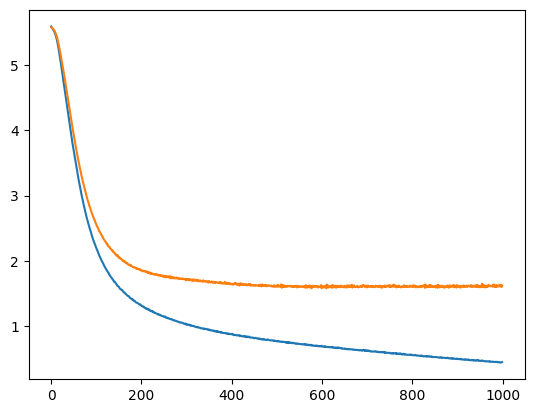

In [28]:
# 17.08.2024.
# documents
# logarithm
plt.plot(train_losses)
plt.plot(val_losses)

In [ ]:
# 17.08.2024.
# documents
# normalization
plt.plot(train_losses)
plt.plot(val_losses)

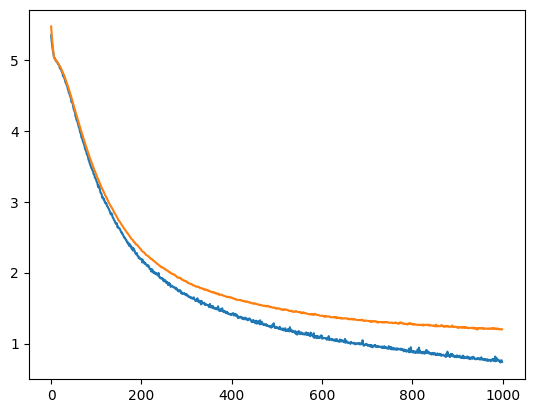

In [29]:
# 17.08.2024.
# books
# no transformation
plt.plot(train_losses)
plt.plot(val_losses)

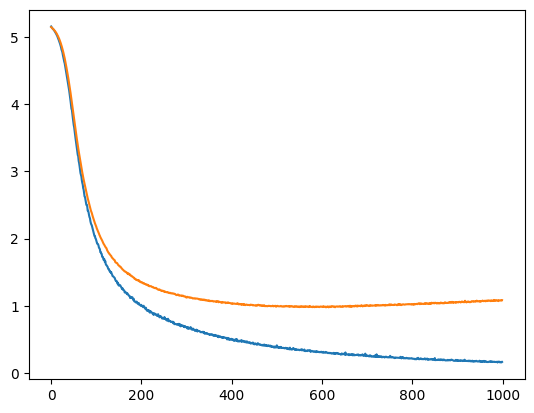

In [28]:
# 17.08.2024.
# books
# logarithm
plt.plot(train_losses)
plt.plot(val_losses)

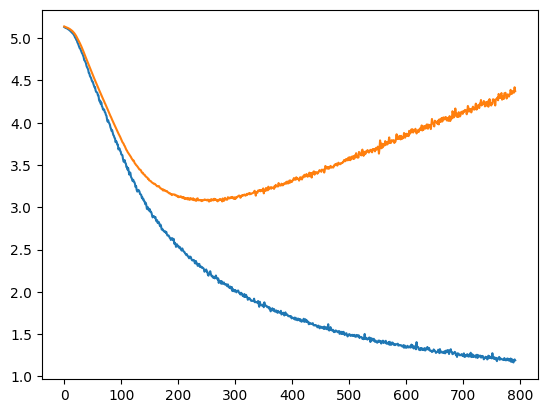

In [28]:
# 17.08.2024.
# books
# normalization
plt.plot(train_losses)
plt.plot(val_losses)

In [29]:
model.eval()
correct = 0
for i, tdata in enumerate(test_loader):
    inputs, labels = tdata
    outputs = model(inputs)
    outputs_class = nn.functional.softmax(outputs).argmax()
    labels_class = labels.argmax()
    correct += (outputs_class == labels_class)*1
acc = float(correct / len(test_loader))

/tmp/ipykernel_15417/3545108458.py:6: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  outputs_class = nn.functional.softmax(outputs).argmax()


In [30]:
acc

0.7531806826591492

In [ ]:
# Books:
# no transformation: 0.70
# normalization: 0.2
# logarithm: 0.85

# Documents:

# logarithm: 0.75


## Visualisation with confusion matrix

In [33]:
model.eval()
correct = 0
labels_saved = []
outputs_saved = []
for i, tdata in enumerate(test_loader):
    inputs, labels = tdata
    outputs = model(inputs)
    outputs_class = nn.functional.softmax(outputs).argmax()
    outputs_saved.append(int(outputs_class))
    labels_class = labels.argmax()
    labels_saved.append(int(labels_class))
    correct += (outputs_class == labels_class)*1
acc = float(correct / len(test_loader))

/tmp/ipykernel_15260/1097759078.py:8: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  outputs_class = nn.functional.softmax(outputs).argmax()


In [34]:
import seaborn as sns

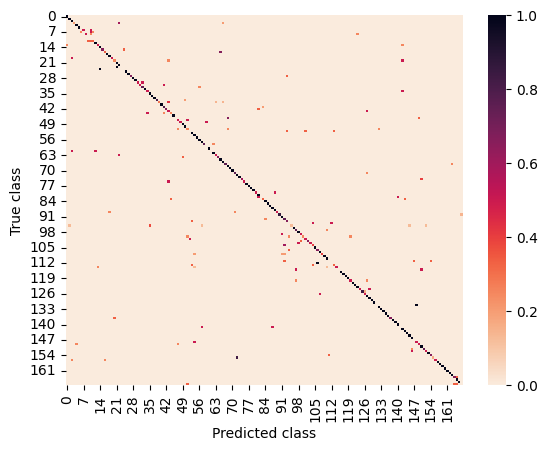

In [35]:
conf_mat = sklearn.metrics.confusion_matrix(labels_saved, outputs_saved, normalize='true')
sns.heatmap(conf_mat, cmap=sns.cm.rocket_r)
plt.ylabel('True class')
plt.xlabel('Predicted class')
plt.savefig('../results/visualisations/heatmap_'+real_or_simulated+'.png')